# Estimating Historical Maximum Wind Speeds and IEC-61400 Standard Requirements on Scotian Shelf

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import genextreme, kstest
import cftime
import xarray as xr
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd

In [2]:
import xarray as xr
import glob

files = sorted(glob.glob(r"C:\Users\jerji\PyCharmMiscProject\Data\ERA5\*.nc"))

print(f"Found {len(files)} files")

ds = xr.open_mfdataset(files, combine='by_coords')

print(list(ds.data_vars))

print(ds.dims)

Found 36 files
['u10', 'v10']
FrozenMappingWarningOnValuesAccess({'valid_time': 315576, 'latitude': 23, 'longitude': 45})


### Calculate wind speed at 100 meters

In [3]:
wind_speed = np.sqrt(ds['u10']**2 + ds['v10']**2)
alpha = 1/7
z_target = 100
z_ref = 10

wind_speed_100m = wind_speed * (z_target / z_ref) ** alpha
wind_speed_100m = wind_speed_100m*1.03
print(wind_speed.shape)

(315576, 23, 45)


In [4]:
print(list(ds.data_vars))

['u10', 'v10']


In [5]:
wind_dom_max = wind_speed_100m.max(dim=['latitude', 'longitude'])

print(wind_dom_max.shape)


(315576,)


### Find Maximum Wind Speed

In [6]:
annual_max = wind_speed_100m.groupby('valid_time.year').max()

In [7]:
lat = ds['latitude']
lon = ds['longitude']

rl50 = np.full((len(lat), len(lon)), np.nan)

### Use Maximum likelihood Estimation (MLE) to calculate Gumbel parameters

In [8]:

def gev_50yr(ts):

    ts = ts[~np.isnan(ts)]

    if len(ts) <= 10:
        return np.nan

    try:
        shape, loc, scale = genextreme.fit(ts)

        return genextreme.ppf(
            0.98,
            shape,
            loc=loc,
            scale=scale
        )

    except:
        return np.nan


# Put full year dimension into one chunk
annual_max = annual_max.chunk({"year": -1})


rl50 = xr.apply_ufunc(
    gev_50yr,
    annual_max,
    input_core_dims=[["year"]],
    vectorize=True,
    output_dtypes=[float],
    dask="parallelized"
)


rl50 = rl50.compute()


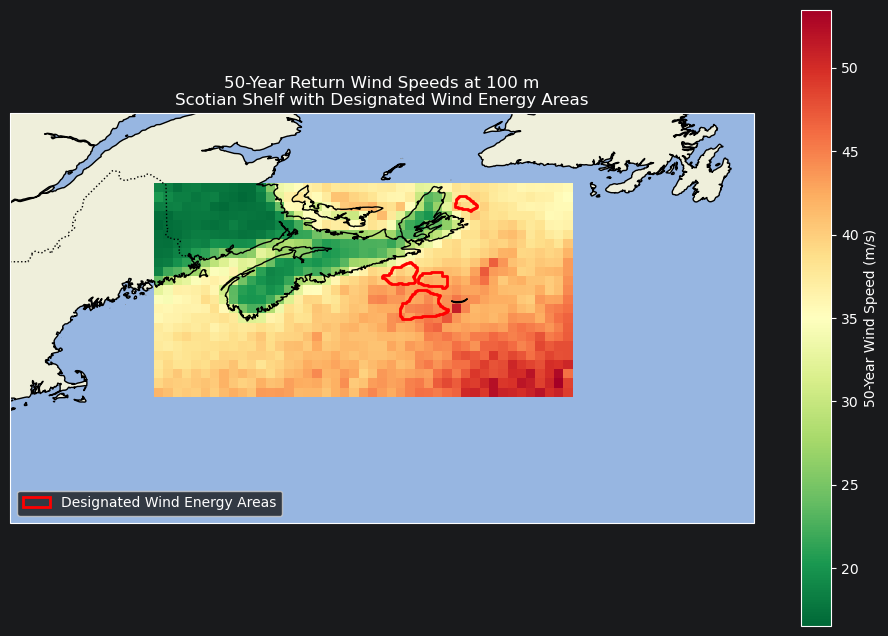

In [9]:
# --------------------------------------------------
# LOAD DESIGNATED WIND ENERGY AREAS SHAPEFILE
# --------------------------------------------------

wea = gpd.read_file(
    r"C:\Users\jerji\PyCharmMiscProject\Data\Designated-WEA\Designated WEA July 29\Designated_WEAs_25_07_29.shp"
)

# --------------------------------------------------
# CREATE FIGURE
# --------------------------------------------------

fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# --------------------------------------------------
# PLOT RETURN LEVEL MAP
# --------------------------------------------------

mesh = ax.pcolormesh(
    lon,
    lat,
    rl50,
    transform=ccrs.PlateCarree(),
    shading='auto',
    cmap='RdYlGn_r'
)

# --------------------------------------------------
# PLOT WIND ENERGY AREAS (Cartopy-safe method)
# --------------------------------------------------

ax.add_geometries(
    wea.geometry,
    crs=ccrs.PlateCarree(),
    facecolor='none',
    edgecolor='red',
    linewidth=2
)

# --------------------------------------------------
# MAP FEATURES
# --------------------------------------------------

ax.coastlines(resolution='10m')
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.BORDERS, linestyle=':')

ax.set_extent([-72, -52, 38, 49], crs=ccrs.PlateCarree())

# --------------------------------------------------
# COLORBAR
# --------------------------------------------------

cbar = plt.colorbar(mesh, ax=ax, orientation='vertical')
cbar.set_label('50-Year Wind Speed (m/s)')

# --------------------------------------------------
# LEGEND (manual, stable)
# --------------------------------------------------

wea_patch = mpatches.Patch(
    facecolor='none',
    edgecolor='red',
    linewidth=2,
    label='Designated Wind Energy Areas'
)

ax.legend(handles=[wea_patch], loc='lower left')

# --------------------------------------------------
# TITLE
# --------------------------------------------------

plt.title(
    '50-Year Return Wind Speeds at 100 m\n'
    'Scotian Shelf with Designated Wind Energy Areas'
)

plt.show()

In [15]:
wea = gpd.read_file(r"C:\Users\jerji\PyCharmMiscProject\Data\Designated-WEA\Designated WEA July 29\Designated_WEAs_25_07_29.shp")

print(wea.columns.tolist())
print(wea.head())

['WEA', 'Area_km2', 'geometry']
                 WEA  Area_km2  \
0        French Bank      3125   
1        Middle Bank      2289   
2  Sable Island Bank      5850   
3       Sydney Bight      1285   

                                            geometry  
0  POLYGON ((-61.75 44.41667, -61.75 44.43333, -6...  
1  POLYGON ((-60.375 44.31667, -60.375 44.33333, ...  
2  POLYGON ((-61.45 43.46667, -61.45 43.48333, -6...  
3  POLYGON ((-59.625 46.38333, -59.625 46.4, -59....  


### Calculate Kholmov Smirnov Test Criteria for 3 random Grid Points

In [10]:

annual_max = wind_speed.groupby('valid_time.year').max()

n_points = 3

np.random.seed(42)

nlat = len(lat)
nlon = len(lon)

print("\n===== KS TEST RESULTS FOR RANDOM GRID POINTS =====\n")

for i in range(n_points):

    lat_idx = np.random.randint(0, nlat)
    lon_idx = np.random.randint(0, nlon)

    data = annual_max.isel(
        latitude=lat_idx,
        longitude=lon_idx
    ).values

    data = data[~np.isnan(data)]

    if len(data) < 10:
        print(f"Point {i+1}: insufficient data\n")
        continue

    shape, loc, scale = genextreme.fit(data)

    ks_result = kstest(
        data,
        'genextreme',
        args=(shape, loc, scale)
    )

    point_lat = lat.values[lat_idx]
    point_lon = lon.values[lon_idx]

    print(f"Point {i+1}")
    print(f"Latitude : {point_lat:.2f}")
    print(f"Longitude: {point_lon:.2f}")

    print("\nGEV Parameters:")
    print(f"Shape (ξ): {shape:.4f}")
    print(f"Location (μ): {loc:.4f}")
    print(f"Scale (σ): {scale:.4f}")

    print("\nKS Test:")
    print(f"KS Statistic: {ks_result.statistic:.4f}")
    print(f"P-value     : {ks_result.pvalue:.4f}")

    if ks_result.pvalue > 0.05:
        print("Result      : PASS (GEV fit acceptable)")
    else:
        print("Result      : FAIL (Reject GEV fit)")

    print("\n" + "="*50 + "\n")


===== KS TEST RESULTS FOR RANDOM GRID POINTS =====

Point 1
Latitude : 45.50
Longitude: -61.00

GEV Parameters:
Shape (ξ): 0.1881
Location (μ): 17.9099
Scale (σ): 1.4046

KS Test:
KS Statistic: 0.1045
P-value     : 0.7886
Result      : PASS (GEV fit acceptable)


Point 2
Latitude : 43.50
Longitude: -57.50

GEV Parameters:
Shape (ξ): 0.0058
Location (μ): 23.4341
Scale (σ): 1.9795

KS Test:
KS Statistic: 0.0756
P-value     : 0.9764
Result      : PASS (GEV fit acceptable)


Point 3
Latitude : 45.25
Longitude: -63.00

GEV Parameters:
Shape (ξ): 0.0050
Location (μ): 11.2159
Scale (σ): 0.9718

KS Test:
KS Statistic: 0.0952
P-value     : 0.8697
Result      : PASS (GEV fit acceptable)




In [18]:
# --------------------------------------------------
# FIND MAX RETURN WIND SPEED IN EACH WEA
# + RECOMMEND IEC TURBINE CLASS
# --------------------------------------------------

rl50_np = rl50.values

results = []

for idx, row in wea.iterrows():

    geom = row.geometry

    mask = np.array([
        geom.contains(gpd.points_from_xy([x], [y])[0])
        for y in lat.values
        for x in lon.values
    ]).reshape(len(lat), len(lon))

    zone_values = rl50_np[mask]

    zone_values = zone_values[~np.isnan(zone_values)]

    if len(zone_values) == 0:
        continue

    vmax = np.max(zone_values)

    if vmax >= 50:
        iec_class = "Class I"

    elif vmax >= 42.5:
        iec_class = "Class II"

    elif vmax >= 37.5:
        iec_class = "Class III"

    else:
        iec_class = "Class IV"

    results.append({
        "Zone Name": row.get("WEA", f"Zone_{idx}"),
        "Max 50-Year Wind Speed (m/s)": round(vmax, 2),
        "Recommended IEC Class": iec_class,
        "Area (km²)": row["Area_km2"]
    })

# --------------------------------------------------
# RESULTS TABLE
# --------------------------------------------------

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Max 50-Year Wind Speed (m/s)",
    ascending=False
)

print(results_df)

           Zone Name  Max 50-Year Wind Speed (m/s) Recommended IEC Class  \
2  Sable Island Bank                         45.35              Class II   
1        Middle Bank                         42.38             Class III   
0        French Bank                         41.85             Class III   
3       Sydney Bight                         40.72             Class III   

   Area (km²)  
2        5850  
1        2289  
0        3125  
3        1285  


In [21]:
# =========================
# DEFINE SCOTIAN SHELF BOUNDS
# =========================

LAT_MIN, LAT_MAX = 41.5, 47.0
LON_MIN, LON_MAX = 360 - 68, 360 - 57  # = 292.0, 303.0

models = ["ACCESS-CM2", "CanESM5-CanOE", "HadGEM3-GC31-LL"]

hist_files = {
    "ACCESS-CM2":      r"C:\Users\jerji\PyCharmMiscProject\Data\CMIP6\sfcWind_Amon_ACCESS-CM2_historical_r1i1p1f1_gn_19900116-20141216.nc",
    "CanESM5-CanOE":   r"C:\Users\jerji\PyCharmMiscProject\Data\CMIP6\sfcWind_Amon_CanESM5-CanOE_historical_r1i1p2f1_gn_19900116-20141216.nc",
    "HadGEM3-GC31-LL": r"C:\Users\jerji\PyCharmMiscProject\Data\CMIP6\sfcWind_Amon_HadGEM3-GC31-LL_historical_r1i1p1f3_gn_19900116-20141216.nc",
}

ssp245_files = {
    "ACCESS-CM2":      r"C:\Users\jerji\PyCharmMiscProject\Data\CMIP6\sfcWind_Amon_ACCESS-CM2_ssp245_r1i1p1f1_gn_20150116-21001216.nc",
    "CanESM5-CanOE":   r"C:\Users\jerji\PyCharmMiscProject\Data\CMIP6\sfcWind_Amon_CanESM5-CanOE_ssp245_r1i1p2f1_gn_20150116-21001216.nc",
    "HadGEM3-GC31-LL": r"C:\Users\jerji\PyCharmMiscProject\Data\CMIP6\sfcWind_Amon_HadGEM3-GC31-LL_ssp245_r1i1p1f3_gn_20150116-21001216.nc",
}

ssp585_files = {
    "ACCESS-CM2":      r"C:\Users\jerji\PyCharmMiscProject\Data\CMIP6\sfcWind_Amon_ACCESS-CM2_ssp585_r1i1p1f1_gn_20150116-21001216.nc",
    "CanESM5-CanOE":   r"C:\Users\jerji\PyCharmMiscProject\Data\CMIP6\sfcWind_Amon_CanESM5-CanOE_ssp585_r1i1p2f1_gn_20150116-21001216.nc",
    "HadGEM3-GC31-LL": r"C:\Users\jerji\PyCharmMiscProject\Data\CMIP6\sfcWind_Amon_HadGEM3-GC31-LL_ssp585_r1i1p1f3_gn_20150116-21001216.nc",
}
# =========================
# SPATIAL SUBSET FUNCTION
# =========================

def subset_region(ds):
    return ds.sel(
        lat=slice(LAT_MIN, LAT_MAX),
        lon=slice(LON_MIN, LON_MAX)
    )


# =========================
# LOAD + SUBSET DATASETS
# =========================

hist   = {m: subset_region(xr.open_dataset(hist_files[m]))   for m in models}
ssp245 = {m: subset_region(xr.open_dataset(ssp245_files[m])) for m in models}
ssp585 = {m: subset_region(xr.open_dataset(ssp585_files[m])) for m in models}

print("===== SUBSETTED SHAPES =====")
for m in models:
    ds = hist[m]["sfcWind"]
    print(f"{m}: lat={ds.lat.values[[0,-1]]}, lon={ds.lon.values[[0,-1]]}, shape={ds.shape}")


# =========================
# SAFE TIME FILTER
# =========================

def filter_years(da, start_year, end_year):
    years = da["time"].dt.year
    return da.where((years >= start_year) & (years <= end_year), drop=True)


# =========================
# HISTORICAL MEAN (1990-2014, 25 years)
# =========================

hist_mean = {
    m: filter_years(hist[m]["sfcWind"], 1990, 2014).mean(dim="time")
    for m in models
}

# =========================
# DELTA FUNCTION (native grid, no regrid)
# =========================

def compute_delta(future_ds, hist_mean_m, start_year, end_year):

    future_var = future_ds["sfcWind"]
    future_period = filter_years(future_var, start_year, end_year)

    if future_period.time.size == 0:
        raise ValueError(f"EMPTY SELECTION: {start_year}-{end_year}.")

    future_mean = future_period.mean(dim="time")

    return future_mean / hist_mean_m


# =========================
# ENSEMBLE DELTA FUNCTION
# Returns ensemble mean delta + std across models
# =========================

def ensemble_delta(future_dict, period):

    start, end = period

    deltas = [
        compute_delta(future_dict[m], hist_mean[m], start, end)
        for m in models
    ]

    scalar_deltas = [d.mean(skipna=True).values.item() for d in deltas]

    mean_delta = np.mean(scalar_deltas)
    std_delta  = np.std(scalar_deltas, ddof=1)  # sample std across models

    print(f"  {start}-{end} model deltas: {[round(x, 5) for x in scalar_deltas]}")
    print(f"           ensemble mean: {mean_delta:.5f} ± {std_delta:.5f}")

    return mean_delta, std_delta


# =========================
# SSP245 RESULTS
# Periods: present (2025-2049), future (2050-2074), end-century (2075-2099)
# All 25-year windows
# =========================

print("\nComputing SSP245 deltas...")
d245_present,    s245_present    = ensemble_delta(ssp245, (2025, 2049))
d245_future,     s245_future     = ensemble_delta(ssp245, (2050, 2074))
d245_endcent,    s245_endcent    = ensemble_delta(ssp245, (2075, 2099))
d245_fullperiod, s245_fullperiod = ensemble_delta(ssp245, (2015, 2099))


# =========================
# SSP585 RESULTS
# =========================

print("\nComputing SSP585 deltas...")
d585_present,    s585_present    = ensemble_delta(ssp585, (2025, 2049))
d585_future,     s585_future     = ensemble_delta(ssp585, (2050, 2074))
d585_endcent,    s585_endcent    = ensemble_delta(ssp585, (2075, 2099))
d585_fullperiod, s585_fullperiod = ensemble_delta(ssp585, (2015, 2099))


# =========================
# SUMMARY TABLE
# =========================

periods = ["2025-2049", "2050-2074", "2075-2099", "2015-2099"]

summary = pd.DataFrame({
    "Period":          periods,
    "SSP245 % change": [(d - 1) * 100 for d in [d245_present, d245_future, d245_endcent, d245_fullperiod]],
    "SSP245 % std":    [s * 100 for s in [s245_present, s245_future, s245_endcent, s245_fullperiod]],
    "SSP585 % change": [(d - 1) * 100 for d in [d585_present, d585_future, d585_endcent, d585_fullperiod]],
    "SSP585 % std":    [s * 100 for s in [s585_present, s585_future, s585_endcent, s585_fullperiod]],
})

summary["SSP2-4.5"] = [
    f"{c:+.2f} ± {s:.2f} %"
    for c, s in zip(summary["SSP245 % change"], summary["SSP245 % std"])
]
summary["SSP5-8.5"] = [
    f"{c:+.2f} ± {s:.2f} %"
    for c, s in zip(summary["SSP585 % change"], summary["SSP585 % std"])
]

print("\n")
print("=" * 55)
print(f"  Wind Speed Change vs. Baseline (1990–2014)")
print("=" * 55)
print(f"  {'Period':<12}  {'SSP2-4.5':>18}  {'SSP5-8.5':>18}")
print("-" * 55)
for _, row in summary.iterrows():
    print(f"  {row['Period']:<12}  {row['SSP2-4.5']:>18}  {row['SSP5-8.5']:>18}")
print("=" * 55)

===== SUBSETTED SHAPES =====
ACCESS-CM2: lat=[41.875 46.875], lon=[293.4375 302.8125], shape=(300, 5, 6)
CanESM5-CanOE: lat=[43.25419467 46.04472663], lon=[292.5    300.9375], shape=(300, 2, 4)
HadGEM3-GC31-LL: lat=[41.875 46.875], lon=[293.4375 302.8125], shape=(300, 5, 6)

Computing SSP245 deltas...
  2025-2049 model deltas: [1.00092, 0.98645, 0.99925]
           ensemble mean: 0.99554 ± 0.00791
  2050-2074 model deltas: [0.99087, 0.98272, 0.99202]
           ensemble mean: 0.98854 ± 0.00507
  2075-2099 model deltas: [0.99589, 0.98386, 0.98892]
           ensemble mean: 0.98955 ± 0.00604
  2015-2099 model deltas: [0.99515, 0.9862, 0.99396]
           ensemble mean: 0.99177 ± 0.00486

Computing SSP585 deltas...
  2025-2049 model deltas: [0.99689, 0.9884, 1.00001]
           ensemble mean: 0.99510 ± 0.00601
  2050-2074 model deltas: [0.98784, 0.95679, 0.9912]
           ensemble mean: 0.97861 ± 0.01897
  2075-2099 model deltas: [0.98539, 0.92479, 0.97278]
           ensemble mean: 0.96

In [24]:
# --------------------------------------------------
# APPLY CMIP6 DELTAS TO ERA5 U50 AND REASSESS IEC CLASS
# --------------------------------------------------

def iec_class(vmax):
    if vmax >= 50:
        return "I"
    elif vmax >= 42.5:
        return "II"
    else:
        return "III"


deltas = {
    "SSP2-4.5 2025-2049": (d245_present, s245_present),
    "SSP2-4.5 2050-2074": (d245_future,  s245_future),
    "SSP2-4.5 2075-2099": (d245_endcent, s245_endcent),
    "SSP5-8.5 2025-2049": (d585_present, s585_present),
    "SSP5-8.5 2050-2074": (d585_future,  s585_future),
    "SSP5-8.5 2075-2099": (d585_endcent, s585_endcent),
}


# --------------------------------------------------
# BUILD PROJECTED RESULTS TABLE
# --------------------------------------------------

projected_results = []

for idx, row in wea.iterrows():

    geom = row.geometry

    mask = np.array([
        geom.contains(gpd.points_from_xy([x], [y])[0])
        for y in lat.values
        for x in lon.values
    ]).reshape(len(lat), len(lon))

    zone_values = rl50_np[mask]
    zone_values = zone_values[~np.isnan(zone_values)]

    if len(zone_values) == 0:
        continue

    vmax      = np.max(zone_values)
    zone_name = row.get("WEA", f"Zone_{idx}")

    entry = {
        "Zone":           zone_name,
        "U50 (m/s)":      round(vmax, 2),
        "IEC (baseline)": iec_class(vmax),
    }

    for scenario, (d, s) in deltas.items():
        v_mid  = vmax * d
        v_low  = vmax * (d - s)
        v_high = vmax * (d + s)
        entry[f"{scenario}|u50"] = f"{v_mid:.1f} [{v_low:.1f}–{v_high:.1f}]"
        entry[f"{scenario}|iec"] = iec_class(v_mid)

    projected_results.append(entry)

proj_df = pd.DataFrame(projected_results)
proj_df = proj_df.sort_values(by="U50 (m/s)", ascending=False)


# --------------------------------------------------
# PRINT TABLE 1 — U50 values
# --------------------------------------------------

ssp245_keys = [k for k in deltas if k.startswith("SSP2")]
ssp585_keys = [k for k in deltas if k.startswith("SSP5")]

periods_short = ["2025-49", "2050-74", "2075-99"]

sep = "-" * 95

print("\n")
print("=" * 95)
print("  50-YEAR RETURN WIND SPEED (m/s)  |  Baseline: ERA5 1990-2014")
print("  Format: mean [lower–upper]  |  Uncertainty = inter-model std (n=3)")
print("=" * 95)
print(f"  {'Zone':<18}  {'ERA5 U50':>8}  {'':5}  {'--- SSP2-4.5 ---':^42}  {'--- SSP5-8.5 ---':^42}")
print(f"  {'':.<18}  {'(m/s)':>8}  {'IEC':>5}  "
      + "  ".join(f"{p:^18}" for p in periods_short)
      + "  "
      + "  ".join(f"{p:^18}" for p in periods_short))
print("  " + sep)

for _, row in proj_df.iterrows():
    vals245 = "  ".join(f"{row[f'{k}|u50']:^18}" for k in ssp245_keys)
    vals585 = "  ".join(f"{row[f'{k}|u50']:^18}" for k in ssp585_keys)
    print(f"  {row['Zone']:<18}  {row['U50 (m/s)']:>8.2f}  {row['IEC (baseline)']:>5}  {vals245}  {vals585}")

print("  " + sep)


# --------------------------------------------------
# PRINT TABLE 2 — IEC classes
# --------------------------------------------------

print("\n")
print("=" * 75)
print("  IEC TURBINE CLASS PROJECTIONS  |  * = change from baseline")
print("=" * 75)
print(f"  {'Zone':<18}  {'Baseline':>8}  "
      + "  ".join(f"{'245 '+p:>8}" for p in periods_short)
      + "  "
      + "  ".join(f"{'585 '+p:>8}" for p in periods_short))
print("  " + "-" * 73)

for _, row in proj_df.iterrows():
    base = row["IEC (baseline)"]

    def fmt(scenario):
        c = row[f"{scenario}|iec"]
        return f"{c+'*':>8}" if c != base else f"{c:>8}"

    print(f"  {row['Zone']:<18}  {base:>8}  "
          + "  ".join(fmt(k) for k in ssp245_keys)
          + "  "
          + "  ".join(fmt(k) for k in ssp585_keys))

print("  " + "-" * 73)
print("  IEC Classes: I (U50≥50), II (≥42.5), III (≥37.5), S (<37.5 — site-specific)")
print("=" * 75)



  50-YEAR RETURN WIND SPEED (m/s)  |  Baseline: ERA5 1990-2014
  Format: mean [lower–upper]  |  Uncertainty = inter-model std (n=3)
  Zone                ERA5 U50                      --- SSP2-4.5 ---                            --- SSP5-8.5 ---             
  ..................     (m/s)    IEC       2025-49             2050-74             2075-99             2025-49             2050-74             2075-99      
  -----------------------------------------------------------------------------------------------
  Sable Island Bank      45.35     II   45.1 [44.8–45.5]    44.8 [44.6–45.1]    44.9 [44.6–45.2]    45.1 [44.9–45.4]    44.4 [43.5–45.2]    43.6 [42.1–45.0] 
  Middle Bank            42.38    III   42.2 [41.9–42.5]    41.9 [41.7–42.1]    41.9 [41.7–42.2]    42.2 [41.9–42.4]    41.5 [40.7–42.3]    40.7 [39.4–42.1] 
  French Bank            41.85    III   41.7 [41.3–42.0]    41.4 [41.2–41.6]    41.4 [41.2–41.7]    41.6 [41.4–41.9]    41.0 [40.2–41.8]    40.2 [38.9–41.6] 
  Sydney B